<a href="https://colab.research.google.com/github/julmiha25-sys/MathStatistica/blob/main/%D0%A1%D1%82%D0%B0%D1%82%D0%B8%D1%81%D1%82%D0%B8%D0%BA%D0%B0_%D0%B4%D0%B5%D0%BC%D0%BE%D0%B3%D1%80%D0%B0%D1%84%D0%B8%D0%B8_%D0%A0%D0%BE%D1%81%D1%81%D0%B8%D0%B8/%D0%9D%D0%B5%D0%BF%D0%B0%D1%80%D0%B0%D0%BC%D0%B5%D1%82%D1%80%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B8%D0%B5_%D0%BA%D1%80%D0%B8%D1%82%D0%B5%D1%80%D0%B8%D0%B8/%D0%A1%D1%82%D0%B0%D1%82%D0%B8%D1%81%D1%82%D0%B8%D0%BA%D0%B0_%D0%BF%D1%80%D0%BE%D0%B4%D0%BE%D0%BB%D0%B6%D0%B8%D1%82%D0%B5%D0%BB%D1%8C%D0%BD%D0%BE%D1%81%D1%82%D0%B8_%D0%B6%D0%B8%D0%B7%D0%BD%D0%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Критерий Крускала-Уоллиса:KruskalResult(statistic=np.float64(18.53863307313024), pvalue=np.float64(9.427292392282461e-05))
Метод множественного сравнения Данна:
         1         2         3
1  1.00000  1.000000  0.001870
2  1.00000  1.000000  0.000212
3  0.00187  0.000212  1.000000
df1_mean=67.66428571428571
df2_mean=66.73071428571427
df3_mean=75.77428571428571


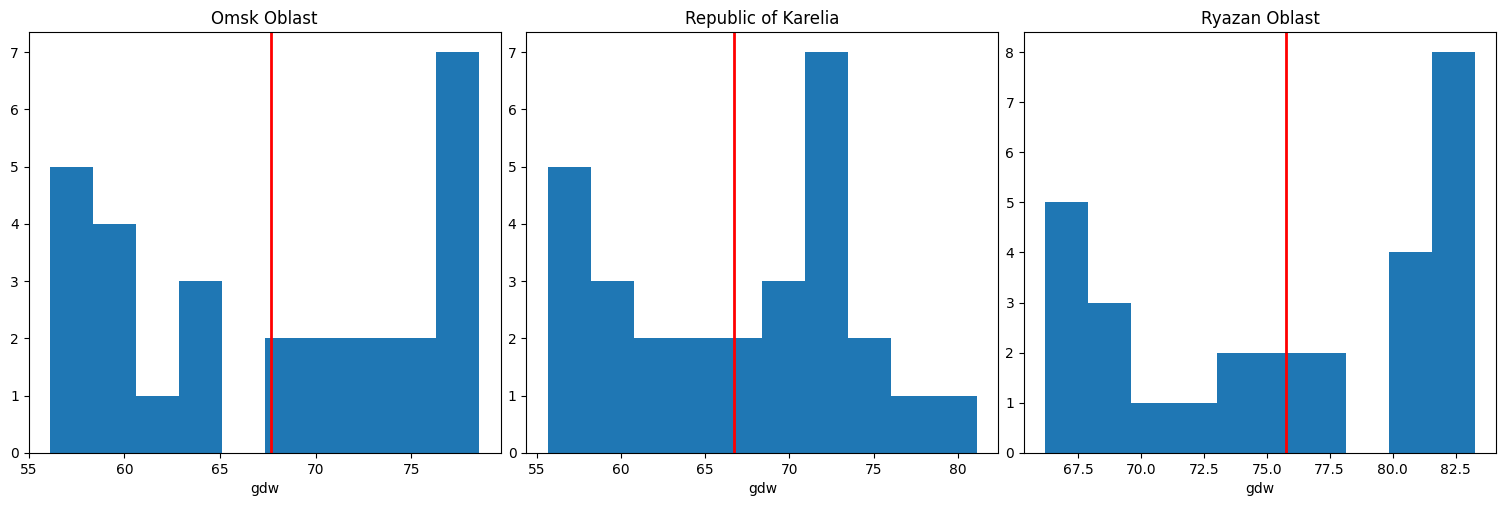

In [3]:
# Проверка гипотезы о равенстве среднего значения коэффициента gdw (продолжительность жизни) в Омской области, Республике Карелии и Рязанской области, используя непараметрические критерии
import pandas as pd
import scikit_posthocs as sp
import scipy.stats
import matplotlib.pyplot as plt
df=pd.read_csv("russian_demography.csv")
df1=df[df['region']=='Omsk Oblast']['gdw']
df2=df[df['region']=='Republic of Karelia']['gdw']
df3=df[df['region']=='Ryazan Oblast']['gdw']
# Визуализация
fig,ax=plt.subplots(1,3,figsize=(15,5))
ax[0].hist(df1)
mean1 = df1.mean()
ax[0].axvline(df1.mean(), color='red', linewidth=2)
ax[1].hist(df2)
ax[1].axvline(df2.mean(), color='red', linewidth=2)
ax[2].hist(df3)
ax[2].axvline(df3.mean(), color='red', linewidth=2)
ax[0].set_title('Omsk Oblast')
ax[1].set_title('Republic of Karelia')
ax[2].set_title('Ryazan Oblast')
ax[0].set_xlabel('gdw')
ax[1].set_xlabel('gdw')
ax[2].set_xlabel('gdw')
fig.tight_layout(pad=0.5)
# Критерий Крускала-Уоллиса
print(f"Критерий Крускала-Уоллиса:{scipy.stats.kruskal(df1,df2,df3)}")
# Гипотезу о равенстве дисперсий отвергаем p=0.00005 < a=0.05
# Метод множественного сравнения Данна
group=[df1,df2,df3]
print(f"Метод множественного сравнения Данна:\n{sp.posthoc_dunn(group, p_adjust = 'bonferroni')}")
# Для гипотезы μ1=μ2 p-value=1 > a=0.05 нет оснований отвергать гипотезу о равенстве средних Омской области и Республики Карелия
# Для гипотезы μ1=μ3 p-value=0.002 < a=0.05, μ2=μ3 p-value=0.0002 < a=0.05 есть основания отвергнуть гипотезу о равенстве средних Рязанской области с Омской областью и Республикой Карелия
# Выборочное среднее для групп - видно, что среднее у 3-й группы (Рязанская область)  сильно отличается от 1 и 2 (у них почти одинаковое)
for i in [(df1,'df1'),(df2,'df2'),(df3,'df3')]:
  print(f"{i[1]}_mean={i[0].mean()}")

In [2]:
pip install scikit_posthocs
